In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar
df_heart = pd.read_csv('02 heartrate_seconds_merged.csv')

In [2]:
# 2. Tamaño
print("Tamaño del DataFrame:")
print(df_heart.shape)


# 3. Primeras filas
print()
print("Primeras filas del DataFrame:")
print(df_heart.head())

# 4. Información general
print()
print("Información general del DataFrame:")
print(df_heart.info())

# 5. Estadísticas
print()
print("Descripción estadística del DataFrame:")
print(df_heart.describe())

# 6. Muestra aleatoria
print()
print("Muestra aleatoria del DataFrame:")
print(df_heart.sample(10))

Tamaño del DataFrame:
(2483658, 3)

Primeras filas del DataFrame:
           Id                  Time  Value
0  2022484408  4/12/2016 7:21:00 AM     97
1  2022484408  4/12/2016 7:21:05 AM    102
2  2022484408  4/12/2016 7:21:10 AM    105
3  2022484408  4/12/2016 7:21:20 AM    103
4  2022484408  4/12/2016 7:21:25 AM    101

Información general del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 2483658 entries, 0 to 2483657
Data columns (total 3 columns):
 #   Column  Dtype
---  ------  -----
 0   Id      int64
 1   Time    str  
 2   Value   int64
dtypes: int64(2), str(1)
memory usage: 56.8 MB
None

Descripción estadística del DataFrame:
                 Id         Value
count  2.483658e+06  2.483658e+06
mean   5.513765e+09  7.732842e+01
std    1.950224e+09  1.940450e+01
min    2.022484e+09  3.600000e+01
25%    4.388162e+09  6.300000e+01
50%    5.553957e+09  7.300000e+01
75%    6.962181e+09  8.800000e+01
max    8.877689e+09  2.030000e+02

Muestra aleatoria del DataFrame:
            

In [3]:
print(df_heart['Id'].nunique())
print()
print(df_heart['Id'].unique())


14

[2022484408 2026352035 2347167796 4020332650 4388161847 4558609924
 5553957443 5577150313 6117666160 6775888955 6962181067 7007744171
 8792009665 8877689391]



Primeras filas del DataFrame:
           Id                Time  Value DayOfWeek
0  2022484408 2016-04-12 07:21:00     97   Tuesday
1  2022484408 2016-04-12 07:21:05    102   Tuesday
2  2022484408 2016-04-12 07:21:10    105   Tuesday
3  2022484408 2016-04-12 07:21:20    103   Tuesday
4  2022484408 2016-04-12 07:21:25    101   Tuesday


C:\Users\andre\AppData\Local\Temp\ipykernel_36308\4248300763.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_heart_withWeek, x='DayOfWeek', order=week_order, palette='rocket')


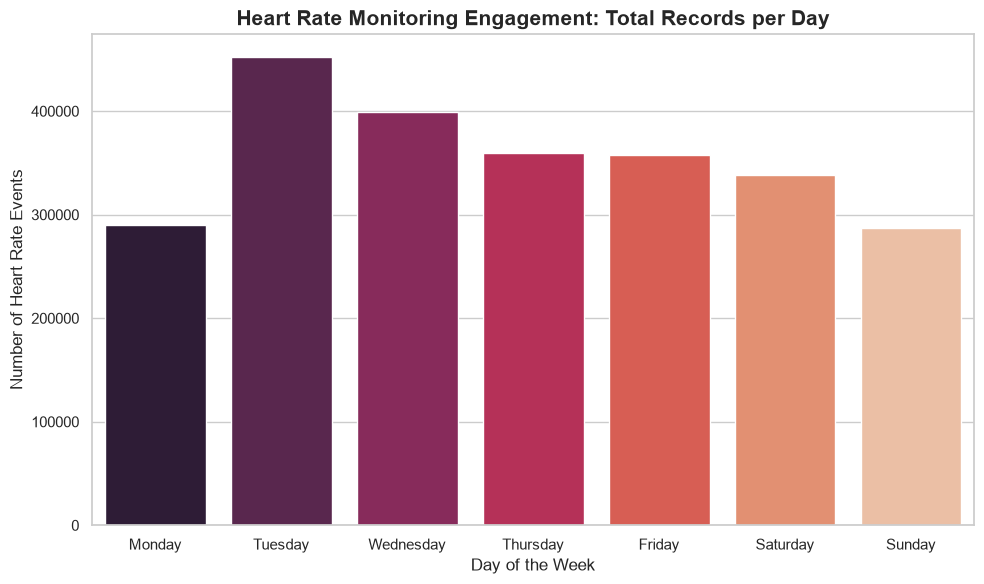

In [5]:
# 2. Convert the Time column to datetime objects
df_heart['Time'] = pd.to_datetime(df_heart['Time'])

# Create a copy to keep the original dataframe intact
df_heart_withWeek = df_heart.copy()

# 3. Extract the Day of the Week
df_heart_withWeek['DayOfWeek'] = df_heart_withWeek['Time'].dt.day_name()

print()
print("Primeras filas del DataFrame:")
print(df_heart_withWeek.head())


# 4. Define the logical order of the week
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 5. Create the count plot
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')
sns.countplot(data=df_heart_withWeek, x='DayOfWeek', order=week_order, palette='rocket')

# 6. English Titles and Labels for Stakeholders
plt.title('Heart Rate Monitoring Engagement: Total Records per Day', fontsize=15, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Heart Rate Events', fontsize=12)

plt.tight_layout()
plt.show()

<class 'pandas.DataFrame'>
Index: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Saturday           24 non-null     float64
 1   Sunday             24 non-null     float64
 2   Weekday (Mon-Fri)  24 non-null     float64
dtypes: float64(3)
memory usage: 672.0 bytes
None

DayType   Saturday     Sunday  Weekday (Mon-Fri)
Hour                                            
0        70.727800  67.813142          65.639163
1        71.576194  66.115867          64.368697
2        71.548888  64.634488          61.802140
3        63.100718  62.569652          60.514786
4        59.532146  61.378398          60.145797


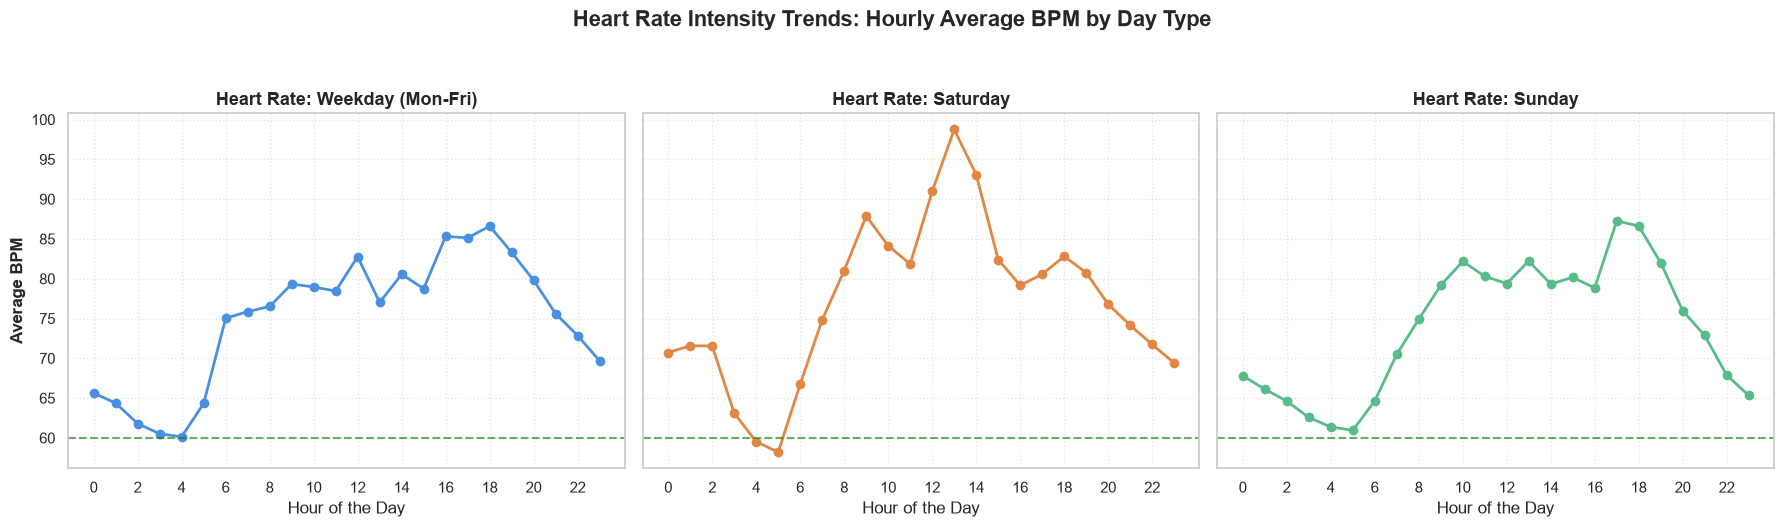

In [14]:
# 1. Prepare the data using a copy to keep the original intact
df_heart_analysis = df_heart.copy()
df_heart_analysis['Time'] = pd.to_datetime(df_heart_analysis['Time'])
df_heart_analysis['Hour'] = df_heart_analysis['Time'].dt.hour
df_heart_analysis['DayName'] = df_heart_analysis['Time'].dt.day_name()




# 2. Categorize by Day Type (Idea 2)
def categorize_day(day):
    if day in ['Saturday']:
        return 'Saturday'
    elif day in ['Sunday']:
        return 'Sunday'
    else:
        return 'Weekday (Mon-Fri)'

df_heart_analysis['DayType'] = df_heart_analysis['DayName'].apply(categorize_day)
#print(df_heart_analysis.head())

# 3. Group by DayType and Hour, calculating the MEAN of Heart Rate (BPM)
df_hr_grouped = df_heart_analysis.groupby(['DayType', 'Hour'])['Value'].mean().unstack(level=0)

print(df_hr_grouped.info())
print()
print(df_hr_grouped.head())

# 4. Visualization: 1 row, 3 subplots (similar to your METs style)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
day_types = ['Weekday (Mon-Fri)', 'Saturday', 'Sunday']
colors = ['#4A90E2', '#E28743', '#57BB8A']

for i, dtype in enumerate(day_types):
    ax = axes[i]
    ax.plot(df_hr_grouped.index, df_hr_grouped[dtype], marker='o', color=colors[i], linewidth=2)

# Agregamos la línea de referencia de ('Healthy Sleep Benchmark')
    ax.axhline(y=60, color='green', linestyle='--', alpha=0.6, label='Healthy Sleep Benchmark')
    
    ax.set_title(f'Heart Rate: {dtype}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Hour of the Day')
    ax.set_xticks(range(0, 24, 2))
    ax.grid(axis='both', linestyle=':', alpha=0.5)


# 4.1 Use a specific axis for the shared y-label (first subplot)
axes[0].set_ylabel('Average BPM', fontsize=12, fontweight='bold')
#axes.set_ylabel('Average BPM', fontsize=12, fontweight='bold')
plt.suptitle('Heart Rate Intensity Trends: Hourly Average BPM by Day Type', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()